In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-07-17 11:16:47,367::INFO::settings.py::Setting loglevel to INFO
2025-07-17 11:16:47,368::INFO::settings.py::Setting stores to {}
2025-07-17 11:16:47,368::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-07-17 11:16:47,369::INFO::settings.py::Setting database.misc.create_tables to True
2025-07-17 11:16:47,369::INFO::settings.py::Setting enable_python_native_blobs to True
2025-07-17 11:16:47,371::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-07-17 11:16:47,371::INFO::settings.py::Setting database.user to celia
2025-07-17 11:16:47,372::INFO::settings.py::Setting database.password to celia
2025-07-17 11:16:47,435::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-07-17 11:16:47,447::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-07-17 11:16:48,155::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,155::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,170::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,170::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,192::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,192::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,215::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,215::INFO::table.py::could not log event in table ~log


In [4]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema.interpolated_trajectories import (
    InterpolatedTrials,
    MeanXYTrajectory,
    MeanVelocities,
    YBinnedXYTrajectory,
)
from vr4mice.schema.session_metrics import TrialMetrics, SessionMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings

warnings.filterwarnings("ignore")


style()

2025-07-17 11:16:48,325::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,325::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,342::INFO::table.py::could not log event in table ~log
2025-07-17 11:16:48,342::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema.vr4mice import State

# From data examples (not on DJ)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
proc_filepath = (
    "/app/vr4mice/videos/test_session/Imagingsource_CeliaTest_2025-07-11_5_PROC"
)

In [8]:
photodiode_data = np.load(proc_filepath, allow_pickle=True)

In [9]:
data = {
    "start_time": photodiode_data["start_time"],
    "photodiode_time": photodiode_data["photodiode_time"],
    "photodiode_read": photodiode_data["photodiode_read"],
    "generated_frame_time": photodiode_data["frame_time"],
    "generated_send_time": photodiode_data["time_stamp"],
    "generated_signal": photodiode_data["signal"],
}

In [10]:
data

{'start_time': array(1.75222979e+09),
 'photodiode_time': array([1.75222979e+09, 1.75222979e+09, 1.75222979e+09, ...,
        1.75223025e+09, 1.75223025e+09, 1.75223025e+09]),
 'photodiode_read': array([ 35.,  38.,  38., ..., 384., 384., 380.]),
 'generated_frame_time': array([1.75222979e+09, 1.75222981e+09, 1.75222981e+09, ...,
        1.75223025e+09, 1.75223025e+09, 1.75223025e+09]),
 'generated_send_time': array([1.75222981e+09, 1.75222981e+09, 1.75222981e+09, ...,
        1.75223025e+09, 1.75223025e+09, 1.75223025e+09]),
 'generated_signal': array([1., 1., 1., ..., 1., 1., 1.])}

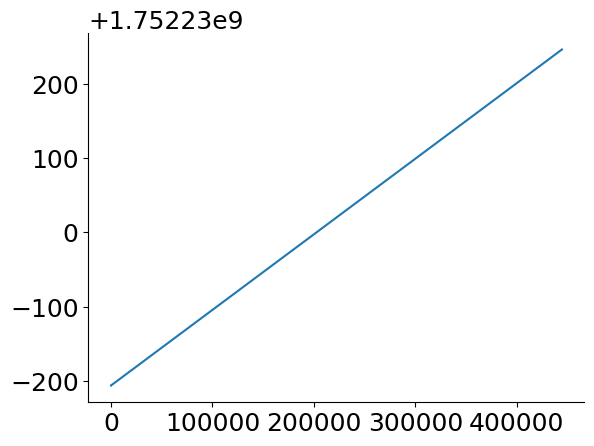

In [11]:
plt.plot(data["photodiode_time"])

In [12]:
dt = [
    data["photodiode_time"][i + 1] - data["photodiode_time"][i]
    for i in range(len(data["photodiode_time"]) - 1)
]
mean_dt = np.mean(dt)

In [13]:
1 / mean_dt

983.2200219727015

In [14]:
from vr4mice.analysis.latency_testing import (
    get_signals,
    detect_signal_polarity,
    filter_pulsed_signal,
)

# signals = get_signals(data, threshold=0.5)

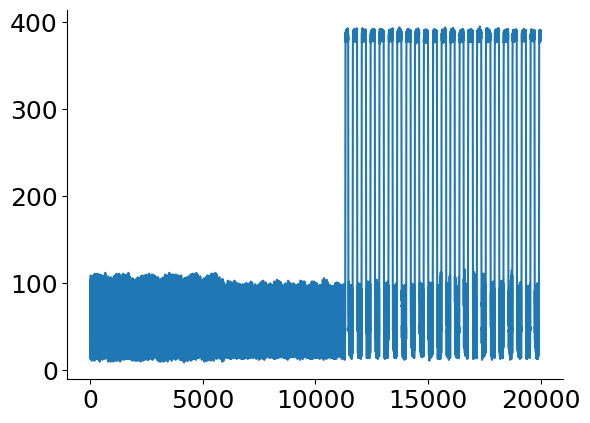

In [15]:
plt.plot(data["photodiode_read"][0:20000])

In [16]:
np.where((data["photodiode_time"] - data["start_time"]) > 1)

(array([   982,    983,    984, ..., 444471, 444472, 444473]),)

min_start:  49.60285132382892


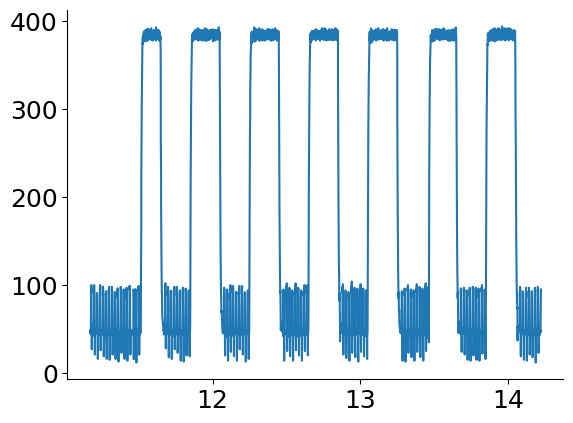

In [17]:
threshold = 0.2
photodiode_read = data["photodiode_read"]
photodiode_time = data["photodiode_time"] - data["start_time"]


min_start = np.mean(photodiode_read[(photodiode_time > 0) & (photodiode_time < 1)])

print("min_start: ", min_start)

# remove first point as this corresponds to the thread starting
if len(photodiode_time) != len(photodiode_read):
    photodiode_read = photodiode_read[1:]

# Cut the 1s start delay to remove the initial noise
photodiode_read = photodiode_read[photodiode_time > 1]
photodiode_time = photodiode_time[photodiode_time > 1]

plt.plot(
    photodiode_time[10000:13000], photodiode_read[10000:13000], label="Photodiode Read"
)

not flipping signal


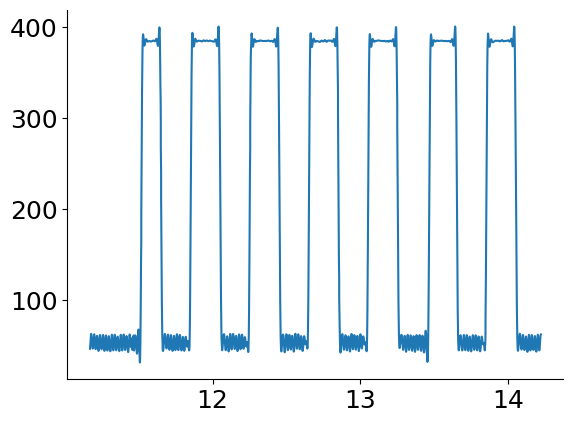

In [18]:
flip_photodiode_signal = detect_signal_polarity(photodiode_read)
filtered_photodiode_read = (
    filter_pulsed_signal(
        photodiode_read, int(1 // np.mean(np.diff(photodiode_time))), cutoff_freq=50
    )
    * flip_photodiode_signal
)

plt.plot(
    photodiode_time[10000:13000],
    filtered_photodiode_read[10000:13000],
    label="Filtered Photodiode Read",
)

In [19]:
# Calculate the mean value prior to signal coming in to scale the signal and scale the trace
filtered_photodiode_scaled = (filtered_photodiode_read - min_start) / (
    np.max(filtered_photodiode_read) - min_start
)

print("min_start", min_start)
print("filtered_photodiode_scaled", filtered_photodiode_scaled)

photodiode_signal_scaled = (photodiode_read - min_start) / (
    np.max(photodiode_read) - min_start
)

# binarise the signal
photodiode_read = filtered_photodiode_scaled > threshold

photodiode = pd.DataFrame(
    {
        "time_stamp": photodiode_time,
        "photodiode_read": photodiode_read,
        "photodiode_raw_scaled": photodiode_signal_scaled,
        "filtered_photodiode_scaled": filtered_photodiode_scaled,
        "threshold": threshold,
    }
)

min_start 49.60285132382892
filtered_photodiode_scaled [-0.1104569  -0.09225643 -0.07399768 ...  0.94420624  0.94140432
  0.93851099]


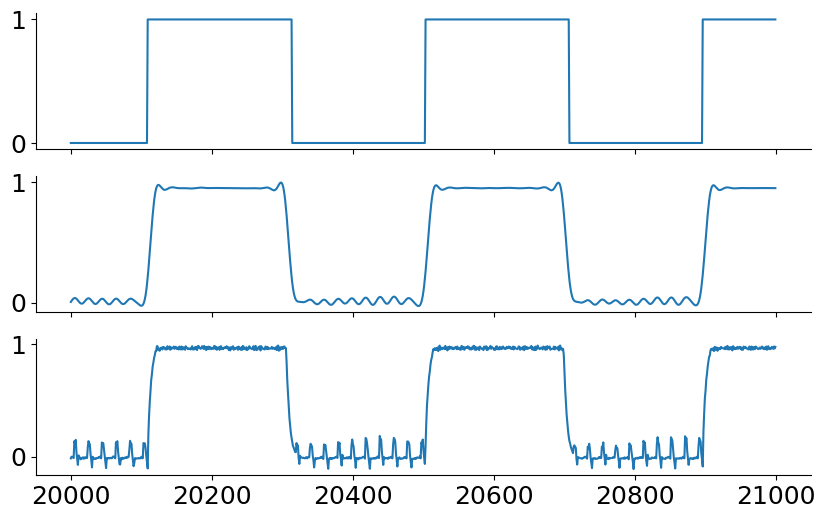

In [20]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
ax[0].plot(photodiode["photodiode_read"][20000:21000])
ax[1].plot(
    photodiode["filtered_photodiode_scaled"][20000:21000],
    label="Filtered Photodiode Read",
)
ax[2].plot(
    photodiode["photodiode_raw_scaled"][20000:21000], label="Photodiode Raw Scaled"
)

In [21]:
photodiode[["photodiode_read"]].to_pickle("photodiode_read.pkl")

In [22]:
video_sync_roi = "/app/vr4mice/videos/test_session/CeliaTest_2025_07_11_sync_roi.mkv"

In [23]:
import cv2
import numpy as np


def extract_sync_signal_from_video(video_path, progress_interval=10000):
    """
    Extract sync signal from a video by calculating mean pixel intensity per frame.

    Args:
        video_path (str): Path to the sync ROI video file
        progress_interval (int): Print progress every N frames (default: 1000)

    Returns:
        tuple: (sync_signal, video_fps, total_frames)
            - sync_signal: numpy array of mean pixel intensities per frame
            - video_fps: frames per second of the video
            - total_frames: total number of frames processed
    """
    # Open video
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}")

    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Processing video: {video_path}")
    print(f"Properties: {width}x{height}, {fps:.2f} fps, {total_frames} frames")

    # Extract sync signal
    sync_signal = []
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        selected_tmp = frame[0, 0].sum()
        sync_signal.append(selected_tmp)

        frame_count += 1

        # Progress update
        if frame_count % progress_interval == 0:
            progress = (frame_count / total_frames) * 100
            print(f"Progress: {progress:.1f}% ({frame_count}/{total_frames} frames)")

    cap.release()

    # Convert to numpy array
    sync_signal = np.array(sync_signal)
    sync_signal = np.where(sync_signal < 400, 0, 1)
    print(f"Extracted sync signal: {len(sync_signal)} frames")
    print(f"Signal range: {np.min(sync_signal):.1f} to {np.max(sync_signal):.1f}")

    return sync_signal

In [24]:
sync_signal = extract_sync_signal_from_video(video_sync_roi)

Processing video: /app/vr4mice/videos/test_session/CeliaTest_2025_07_11_sync_roi.mkv
Properties: 20x20, 120.00 fps, 54010 frames
Progress: 18.5% (10000/54010 frames)
Progress: 37.0% (20000/54010 frames)
Progress: 55.5% (30000/54010 frames)
Progress: 74.1% (40000/54010 frames)
Progress: 92.6% (50000/54010 frames)
Extracted sync signal: 54010 frames
Signal range: 0.0 to 1.0


In [25]:
np.save("sync_signal.npy", sync_signal)

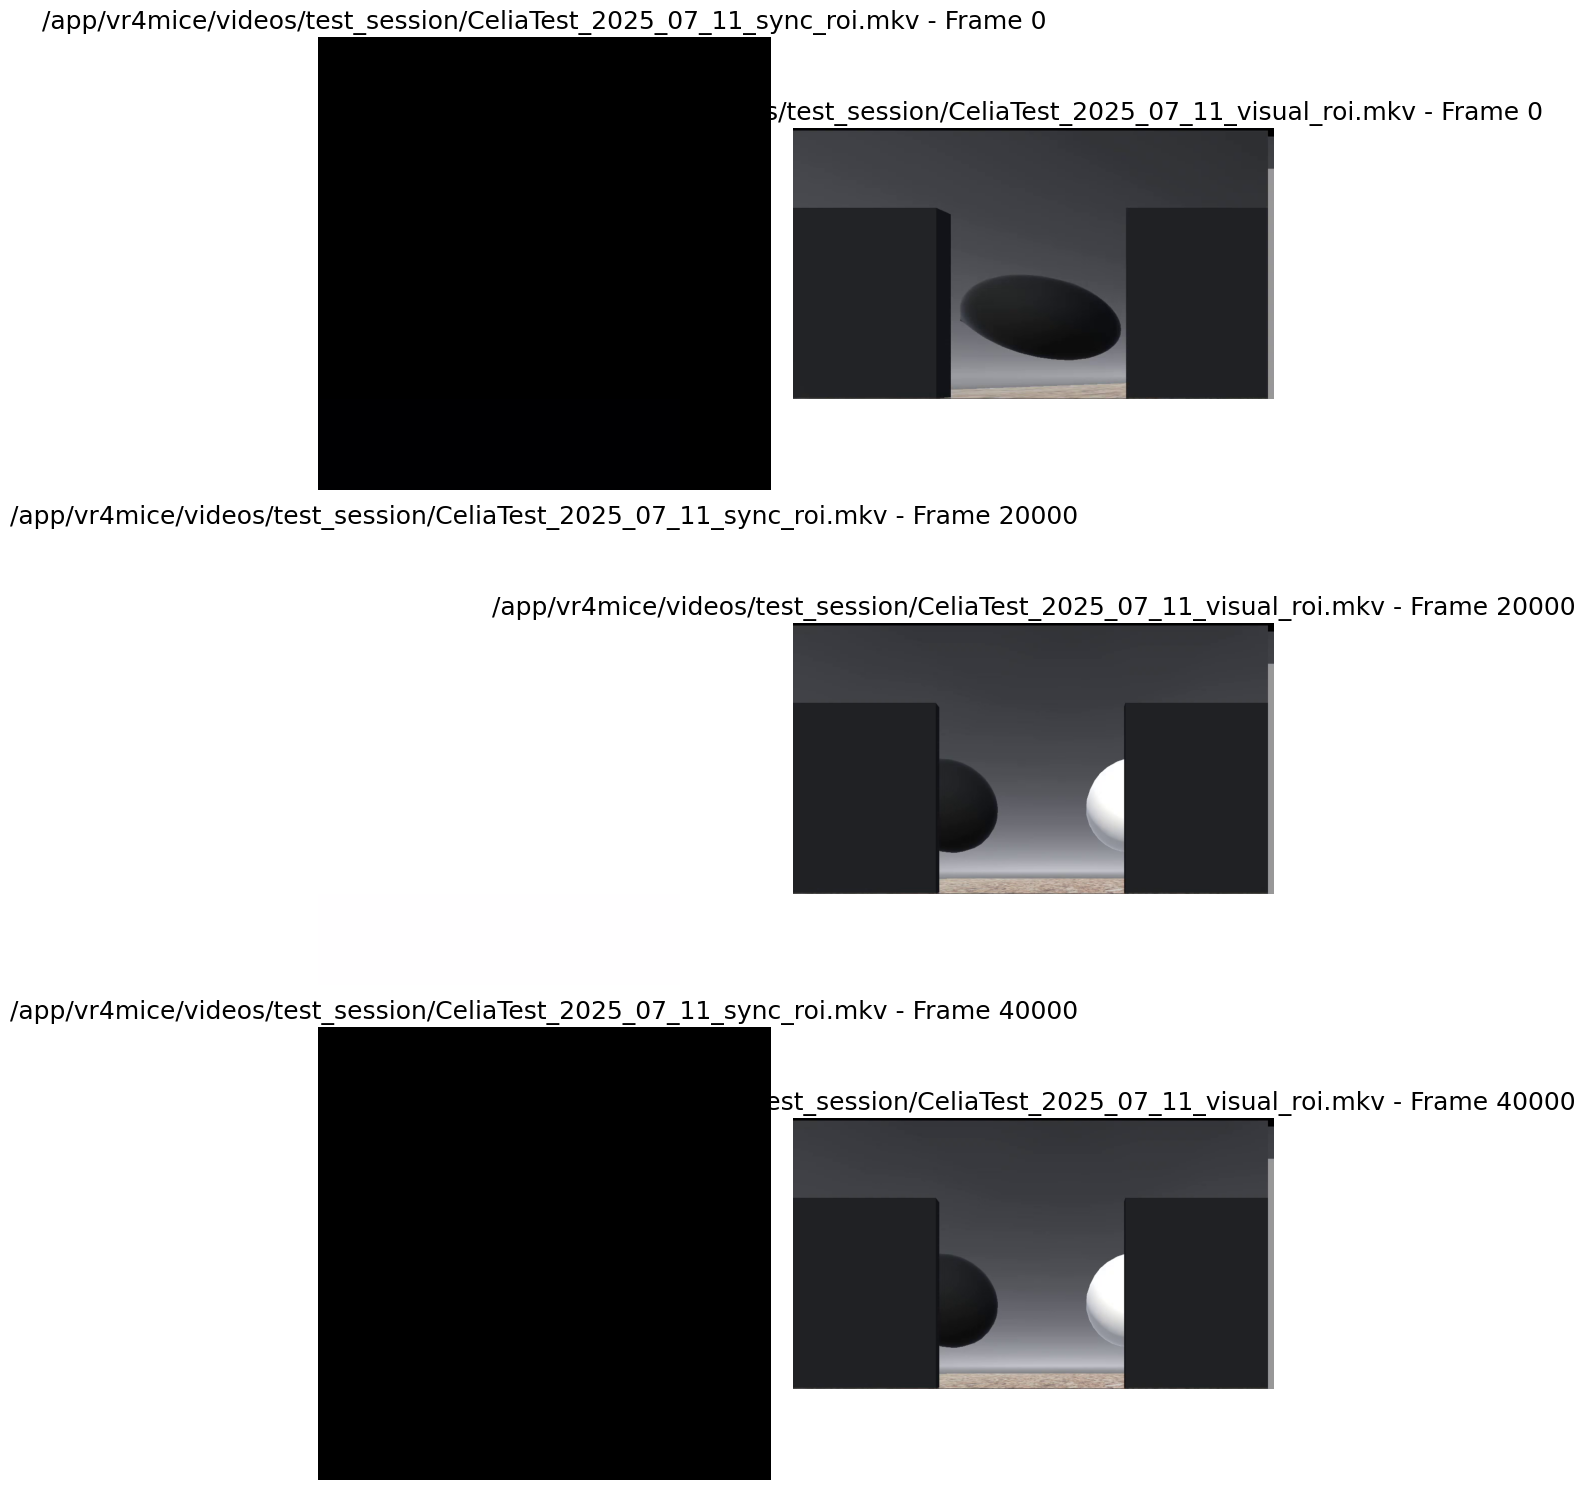

In [26]:
import cv2
import matplotlib.pyplot as plt


def extract_frames(video_path, frame_indices):
    cap = cv2.VideoCapture(video_path)
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
    cap.release()
    return frames


# Example usage
video1 = "/app/vr4mice/videos/test_session/CeliaTest_2025_07_11_sync_roi.mkv"
video2 = "/app/vr4mice/videos/test_session/CeliaTest_2025_07_11_visual_roi.mkv"
frame_indices = [0, 20000, 40000]  # replace with desired frame numbers

frames1 = extract_frames(video1, frame_indices)
frames2 = extract_frames(video2, frame_indices)

# Plot
fig, axs = plt.subplots(len(frame_indices), 2, figsize=(10, 5 * len(frame_indices)))
for i, (f1, f2) in enumerate(zip(frames1, frames2)):
    axs[i, 0].imshow(f1)
    axs[i, 0].set_title(f"{video1} - Frame {frame_indices[i]}")
    axs[i, 0].axis("off")
    axs[i, 1].imshow(f2)
    axs[i, 1].set_title(f"{video2} - Frame {frame_indices[i]}")
    axs[i, 1].axis("off")
plt.tight_layout()
plt.show()

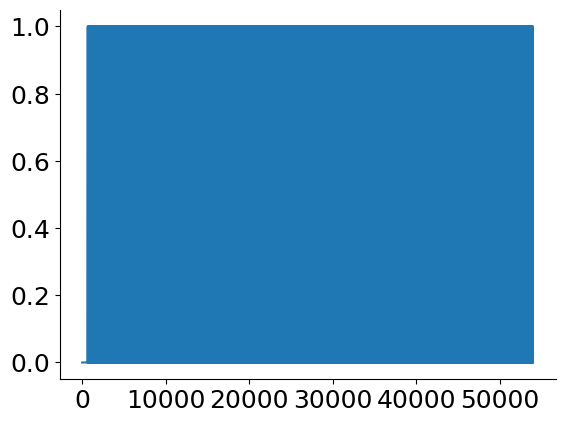

In [27]:
plt.plot(sync_signal)

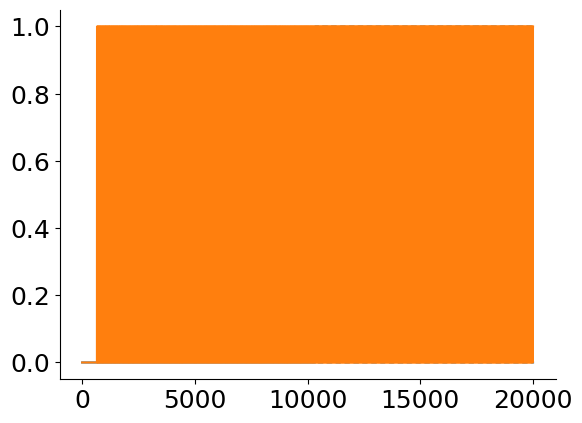

In [28]:
plt.plot(photodiode["photodiode_read"][:20000])
plt.plot(sync_signal[:20000])

# From DJ directly

In [29]:
from vr4mice.schema.vr4mice import SignalsPhotodiode

SignalsPhotodiode()

dataset,start_time,photodiode_time timestamp of the photodiode signal,photodiode_read value of the photodiode signal,generated_frame_time timestamp of frame relative to the generated signal,generated_send_time time that the signal gets sent from the dlc processor,generated_signal the signal that is generated by the dlc processor
Jacana_2024-07-26_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-27_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-28_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Jacana_2024-07-29_2,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_1,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_2,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_3,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_4,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_5,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=
Latencytest1_2024-10-31_6,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=,=BLOB=


In [30]:
from vr4mice.schema.vr4mice import SignalsPhotodiode

df = pd.DataFrame(
    {
        "photodiode_read": (
            SignalsPhotodiode() & {"dataset": "Latencytest2_2025-05-19_2"}
        ).fetch1("photodiode_read")
    }
)

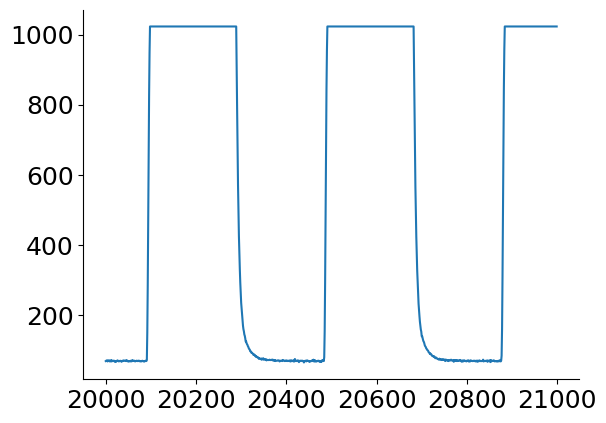

In [31]:
plt.plot(df["photodiode_read"][20000:21000])

In [32]:
from vr4mice.analysis.latency_testing import get_signals, find_rising_edges, get_latency

In [33]:
# This fecth call takes some time as the photodide is sampled at 1000 hz
start_time = df_data.time_stamp[np.where(df_data.signal_read == 1)[0][0]]
print("start_time", start_time)

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(df_data.time_stamp, df_data.signal_read, c="black", linewidth=2)


ax[1].plot(df_data.time_stamp, df_data.photodiode_raw_scaled, c="#AE18D3", linewidth=2)

ax[2].plot(df_data.time_stamp, df_data.signal_read, c="black", linewidth=2, alpha=0.8)
ax[2].plot(
    df_data.time_stamp, df_data.photodiode_read, c="#AA1BCE", linewidth=2, alpha=0.8
)

# for ft, td in zip(latencies.frame_time, latencies.time_diff):
#     ax[2].annotate(round(td*1000, 2), (ft, 1.1))

ax[1].set_ylim(-0.2, 1.3)

ax[1].axhline(0.3, c="red", linestyle="dashed", alpha=0.5, linewidth=3)
ax[2].set_ylim(-0.2, 1.3)


sns.despine(offset=10)

for a in ax:
    a.axis("off")
    a.set_xlim(start_time - 1, start_time + 3)

NameError: name 'df_data' is not defined

In [ ]:
df.to_pickle("photodiode_read.pkl")

In [ ]:
df_test = pd.read_pickle("/app/photodiode_read.pkl")

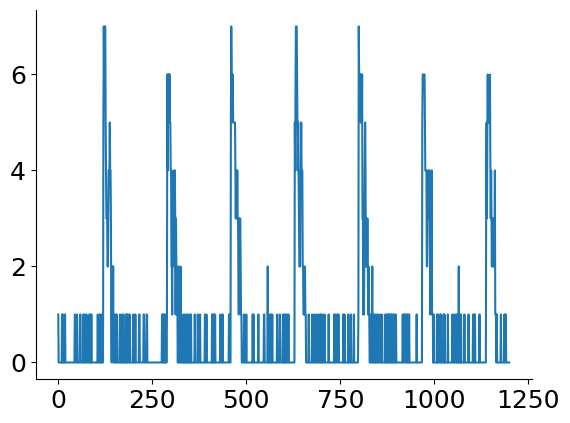

In [ ]:
plt.plot(df_test["photodiode_read"][:1200])

In [ ]:
# This fecth call takes some time as the photodide is sampled at 1000 hz
rising_edges_signal = find_rising_edges(df_test.time_stamp, df.signal_read)
rising_edges_photodiode = find_rising_edges(df.time_stamp, df.photodiode_read)
latencies = get_latency(rising_edges_signal, rising_edges_photodiode)

start_time = df.time_stamp[np.where(df.signal_read == 1)[0][0]]
print("start_time", start_time)

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(df.time_stamp, df.signal_read, c="black", linewidth=2)


ax[1].plot(df.time_stamp, df.photodiode_raw_scaled, c="#AE18D3", linewidth=2)

ax[2].plot(df.time_stamp, df.signal_read, c="black", linewidth=2, alpha=0.8)
ax[2].plot(df.time_stamp, df.photodiode_read, c="#AA1BCE", linewidth=2, alpha=0.8)

for ft, td in zip(latencies.frame_time, latencies.time_diff):
    ax[2].annotate(round(td * 1000, 2), (ft, 1.1))

ax[1].set_ylim(-0.2, 1.3)

ax[1].axhline(0.3, c="red", linestyle="dashed", alpha=0.5, linewidth=3)
ax[2].set_ylim(-0.2, 1.3)


sns.despine(offset=10)

for a in ax:
    a.axis("off")
    a.set_xlim(start_time - 1, start_time + 3)

In [ ]:
import cv2

threshold = None  # Set to None for auto-detection
cap = cv2.VideoCapture("/app/vr4mice/videos/Jacana_2024-07-26 _1_sync_roi.mkv")

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

print(f"Processing sync video: {total_frames} frames at {fps:.2f} fps")

sync_values = []
frame_indices = []

frame_idx = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale and get mean intensity
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    mean_intensity = np.mean(gray_frame)

    sync_values.append(mean_intensity)
    frame_indices.append(frame_idx)
    frame_idx += 1

    # Progress update
    if frame_idx % 1000 == 0:
        print(f"  Processed {frame_idx}/{total_frames} frames...")

cap.release()

video_sync_signal = np.array(sync_values)
video_frame_indices = np.array(frame_indices)
video_fps = fps

# Auto-detect threshold if not provided
if threshold is None:
    threshold = np.mean(video_sync_signal) + np.std(video_sync_signal)
    print(f"Auto-detected threshold: {threshold:.2f}")

# Convert to binary signal
video_sync_binary = (video_sync_signal > threshold).astype(int)

print(f"Extracted video sync signal: {len(video_sync_signal)} samples")

In [ ]:
video_sync_signal

In [ ]:
seconds = 2828.939302
print(f"Total duration: {seconds} seconds")

Total duration: 2828.939302 seconds


In [ ]:
import cv2


def count_frames_opencv(video_path):
    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return frame_count


# Usage
video_path = "/app/vr4mice/videos/Nightingale_2024-08-14_1_visual_roi.mkv"
frames = count_frames_opencv(video_path)
print(f"Total frames: {frames}")

Total frames: 339565


In [ ]:
seconds = frames / 120
print(f"Total duration: {seconds} seconds")

Total duration: 2829.7083333333335 seconds
